In [1]:
import rasterio
import os
import subprocess
import matplotlib.pyplot as plt

### This NB aggregates and coarsens chm data from the original Lidar data.
1. The first step aggregates the individuals tifs into one tif per site
2. The second step coarsens data to the resolution of a target image tif.
   - aggregation takes the average value of cells that are not nodata

In [2]:
#data_dir = '/Users/estherrolf/research/tree_mapping/data'
data_dir = "/n/home10/erolf/tree_mapping/data"

In [5]:
Karingani_sites = ['20210601_KaringaniMassingirDevNode',
 '20210527_KaringaniSite14',
 '20210524_KaringaniSite16',
 '20210531_KaringaniVultureSite01',
 '2021-05-15_KaringaniSungoloDevNode',
 '20210522_KaringaniSite17',
 '20210530_KaringaniSite13',
 '20210529_KaringaniSite15',
 '20210507_KaringaniSite11DevNodeF',
 '20210510_KaringaniSite01',
 '20210523_KaringaniSite12',
 '20210517_KaringaniSite08',
 '20210525_KaringaniSouthSouthDevNode',
 '20210518_KaringaniSite06',
 '20210512_KaringaniSite05']

all_site_ids = [x.split('_')[1] for x in Karingani_sites]

In [4]:
def tifs_to_input_fns(tifs):

    fns_as_input = []
    for tif in tifs:
        fns_as_input +=  [tif]
    fns_as_input
    
    return fns_as_input

def merge_tifs(tifs_to_merge, out_tif_fp, verbose=True):
    # find all tifs in the site folder
    input_files = tifs_to_merge 
    if verbose: print(len(tifs_to_merge))
    # merge
    command = ["gdal_merge.py",
           "-ot", "Float32", 
           "-of", "GTiff", 
           "-o", out_tif_fp,
           "-n", "-9999.",
           "-a_nodata", "-9999.",
          ] + input_files
    subprocess.call(command)

In [6]:
def aggregate_lidar(site_dir, out_tif_fp):
    # find all tifs in the site folder
    
    tifs_to_merge = [f'{site_dir}/{x}'  for x in os.listdir(site_dir) if x.endswith('.tif')]
    
    merge_tifs(tifs_to_merge, out_tif_fp)


#     input_files = tifs_to_merge #tifs_to_input_fns(tifs_to_merge)
#     print(len(tifs_to_merge))
#     # merge
#     command = ["gdal_merge.py",
#            "-ot", "Float32", 
#            "-of", "GTiff", 
#            "-o", out_tif_fp,
#            "-n", "-9999.",
#            "-a_nodata", "-9999.",
#           ] + input_files
#     subprocess.call(command)
    
    # assign CRS EPSG:32736 (CRS of the original Lidar data)
    command = ["gdal_edit.py",
               "-a_srs", "EPSG:32736", 
               "-a_nodata", "-9999.",
               out_tif_fp]
    subprocess.call(command)
    
    print(f'merged data saved in {out_tif_fp}')
          
    return out_tif_fp

## step 1 - aggregate the files in each folder to one tif


In [8]:
if not os.path.exists(f'{data_dir}/lidar/Karingani_merged_crs'):
    os.mkdir(f'{data_dir}/lidar/Karingani_merged_crs')
    print('made dir ',f'{data_dir}/lidar/Karingani_merged_crs')

In [9]:
fns_1m = []
for site_name in Karingani_sites:
    print(site_name)
    site_id = site_name.split('_')[1]

    
    site_dir = f'{data_dir}/lidar/karingani_int/{site_name}/CHM'
    output_fn_agg = f'{data_dir}/lidar/Karingani_merged_crs/{site_id}_CHM_1m_merged.tif'
    out_fn = aggregate_lidar(site_dir, output_fn_agg)
    fns_1m.append(out_fn)

20210601_KaringaniMassingirDevNode
63
0...10...20...30...40...50...60...70...80...90...100 - done.
merged data saved in /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniMassingirDevNode_CHM_1m_merged.tif
20210527_KaringaniSite14
30
0...10...20...30...40...50...60...70...80...90...100 - done.
merged data saved in /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniSite14_CHM_1m_merged.tif
20210524_KaringaniSite16
29
0...10...20...30...40...50...60...70...80...90...100 - done.
merged data saved in /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniSite16_CHM_1m_merged.tif
20210531_KaringaniVultureSite01
12
0...10...20...30...40...50...60...70...80...90...100 - done.
merged data saved in /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniVultureSite01_CHM_1m_merged.tif
2021-05-15_KaringaniSungoloDevNode
1
0...10...20...30...40...50...60...70...80...90...100 - done.
merged data saved in /n/home10/erolf/tree_mappin



## step 2 - coarsen chm data to the resolution of the imagery



In [8]:
if not os.path.exists(f'{data_dir}/lidar/Karingani_merged_crs_10'):
    os.mkdir(f'{data_dir}/lidar/Karingani_merged_crs_10')
    print('made dir ',f'{data_dir}/lidar/Karingani_merged_crs_10')

In [9]:
def coarsen_lidar(input_fn,
                  output_fn,
                  target_fn):

    # aggregate to the resolution of the target_fn
    TMP_FN = '../data/tmp/tmp.tif'
    
    with rasterio.open(target_fn, "r") as f:
        left, bottom, right, top = f.bounds
        crs = f.crs.to_string()
        height, width = f.height, f.width
   
    command = [
        "gdalwarp",
        "-overwrite",
        "-ot", "Float32",
        "-t_srs", crs,
        "-r", "average",  # this is the important bit
        "-of", "GTiff",
        "-te", str(left), str(bottom), str(right), str(top),
        "-ts", str(width), str(height),
        "-co", "COMPRESS=LZW",
        "-co", "BIGTIFF=YES",
        "-srcnodata", "-9999.",
        "-dstnodata", "-9999.",
        input_fn,
        TMP_FN
    ]
    subprocess.call(command)
    
    # now crop to the original extend of the input file
    with rasterio.open(input_fn, "r") as f:
        left, bottom, right, top = f.bounds
        crs = f.crs.to_string()
        height, width = f.height , f.width
    
    command = [
        "gdalwarp",
        "-overwrite",
        "-ot", "Float32",
        "-t_srs", crs,
    #    "-r", "average",  # this is the important bit
        "-of", "GTiff",
        "-te", str(left), str(bottom), str(right), str(top),
        #"-ts", str(width), str(height),
        "-co", "COMPRESS=LZW",
        "-co", "BIGTIFF=YES",
        "-srcnodata", "-9999.",
        "-dstnodata", "-9999.",
        TMP_FN,
        output_fn
    ]
    subprocess.call(command)

In [12]:
begining_sentinel_tile = f'{data_dir}/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704/T36KVU_20230418T073611_B02_10m.tif'


for fn_1m in fns_1m:
    input_fn = fn_1m
    site_id = input_fn.split('/')[-1].split('_')[0]
    output_fn = input_fn.replace('1m_merged.tif', 
                                 '10m_merged.tif').replace('Karingani_merged_crs',f'Karingani_merged_crs_10/{site_id}')

    if not os.path.exists(f"{data_dir}/lidar/Karingani_merged_crs_10/{site_id}"):
        os.mkdir(f"{data_dir}/lidar/Karingani_merged_crs_10/{site_id}")
    coarsen_lidar(input_fn,
                  output_fn, 
                  target_fn=begining_sentinel_tile)

Creating output file that is 10980P x 10980L.
Processing /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniMassingirDevNode_CHM_1m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 639P x 270L.
Processing ../data/tmp/tmp.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 10980P x 10980L.
Processing /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniSite14_CHM_1m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 479P x 491L.
Processing ../data/tmp/tmp.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 10980P x 10980L.
Processing /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniSite16_CHM_1m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 479P x 486L.
P

## step 3 - merge all into one file
We will use this tif to crop the sentinel tile into a smaller one for running eval.

In [6]:
site_ids = Karingani_sites
#test_site_ids = ["KaringaniSite11DevNodeF","KaringaniSite12","KaringaniSite16"]

In [8]:
all_site_ids

['KaringaniMassingirDevNode',
 'KaringaniSite14',
 'KaringaniSite16',
 'KaringaniVultureSite01',
 'KaringaniSungoloDevNode',
 'KaringaniSite17',
 'KaringaniSite13',
 'KaringaniSite15',
 'KaringaniSite11DevNodeF',
 'KaringaniSite01',
 'KaringaniSite12',
 'KaringaniSite08',
 'KaringaniSouthSouthDevNode',
 'KaringaniSite06',
 'KaringaniSite05']

In [9]:
import sys
sys.path.append('..')
from importlib import reload
import utils
reload(utils)

input_fn = '/n/home10/erolf/tree_mapping/data/sentinel/'
sentinel_dir = '/n/home10/erolf/tree_mapping/data/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704'


for s2_fn in list(os.listdir(sentinel_dir)):
    if not s2_fn.endswith('.tif'): continue
    input_fn = os.path.join(sentinel_dir, s2_fn)
    
    for site_id in all_site_ids:
        target_fn = f'/n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/{site_id}_CHM_1m_merged.tif'
        chunked_sentinel_dir = '/n/home10/erolf/tree_mapping/data/int/sentinel_by_site'
        if not os.path.exists(chunked_sentinel_dir): os.mkdir(chunked_sentinel_dir)
        if not os.path.exists(f"{chunked_sentinel_dir}/{site_id}"): os.mkdir(f"{chunked_sentinel_dir}/{site_id}")
        output_fn = f"{chunked_sentinel_dir}/{site_id}/{s2_fn}"

        utils.crop_input_to_target_tif(input_fn, 
                                        output_fn, 
                                        target_fn, 
                                        buffer = 200, 
                                        verbose=True)

['gdalwarp', '-overwrite', '-ot', 'Float32', '-t_srs', 'EPSG:32736', '-r', 'average', '-of', 'GTiff', '-te', '390213.0', '7349296.0', '397004.0', '7352396.0', '-co', 'COMPRESS=LZW', '-co', 'BIGTIFF=YES', '-dstnodata', '-9999', '/n/home10/erolf/tree_mapping/data/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704/T36KVU_20230418T073611_B04_10m.tif', '/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/KaringaniMassingirDevNode/T36KVU_20230418T073611_B04_10m.tif']
Creating output file that is 679P x 310L.
Processing /n/home10/erolf/tree_mapping/data/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704/T36KVU_20230418T073611_B04_10m.tif [1/1] : 0Using internal nodata values (e.g. 0) for image /n/home10/erolf/tree_mapping/data/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704/T36KVU_20230418T073611_B04_10m.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
saved in /n/home10/erolf/tree_mapping/data/int/sentinel_by_site/KaringaniMassingi

In [41]:
check_fp = '/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/KaringaniSite11DevNodeF/T36KVU_20230418T073611_TCI_10m.tif'

with rasterio.open(check_fp) as f:
    data = f.read()

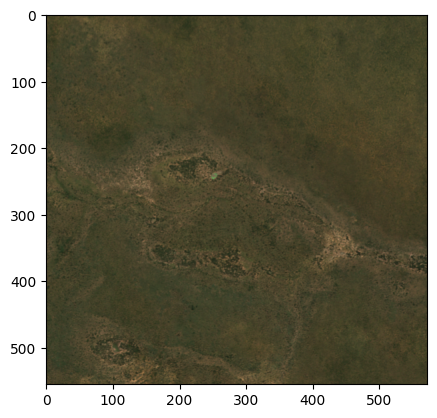

In [42]:
plt.imshow(data.transpose(1,2,0) / 255. )

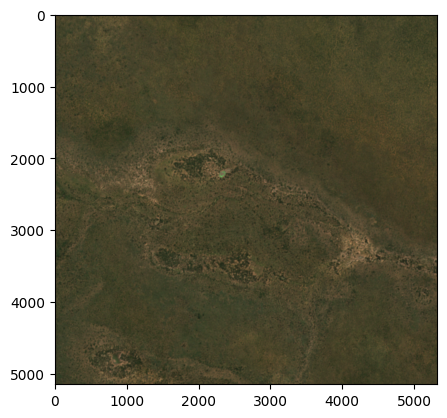

In [27]:

plt.imshow(data.transpose(1,2,0) / 255. )